# 1. Using Numpy array, create and image with two circle and a structuring elemnet. Perform morphological Erosion and Dilation using built-in function. Show the original image, SE, eroded image and dilated image side by side in a subplot with a title.

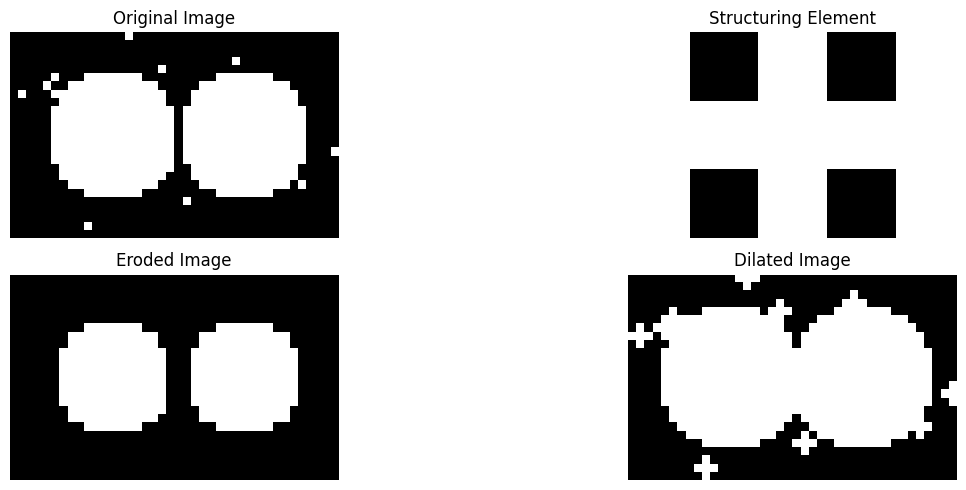

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.draw import disk
from skimage.morphology import (erosion, dilation, closing, opening, area_closing, area_opening)
from skimage.color import rgb2gray

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
element=np.array([[0,1,0],[1,1,1],[0,1,0]])
#plt.imshow(element, cmap='gray');

# to demonstrate how morphological operations work, let us create two adjacent circle with random noise on its bg.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1
for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1

#imshow(circle_image)
#Erosion removes islands and small objects so that only the key features will remain. Meanwhile, dilation makes objects more visible and fills in small holes in objects.
erosion=erosion(circle_image, element);
dilation=dilation(circle_image, element);

#plot the img
plt.figure(figsize=(15,5))

#plot the original img
plt.subplot(2,2,1)
plt.imshow(circle_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

#plot the structuring element
plt.subplot(2,2,2)
plt.imshow(element, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')

#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(erosion, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(dilation, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()

#Notice how the eroded image is smaller than the original image , this is because the outer most layer of the cirlces is eroded. This operation also erded the random noise in the background. On the flip side , the dilated image did the opposite the two circles expanded to the point that they already touched each other. Moreover, the random noise grew using the dilation operation.

# 2. Using Numpy array, create an image with two circle and a structuring element. Perform morphological Erosion and Dilation without using built in function. Show the original image, SE, eroded image and dilated image side by side in a subplot with a title.

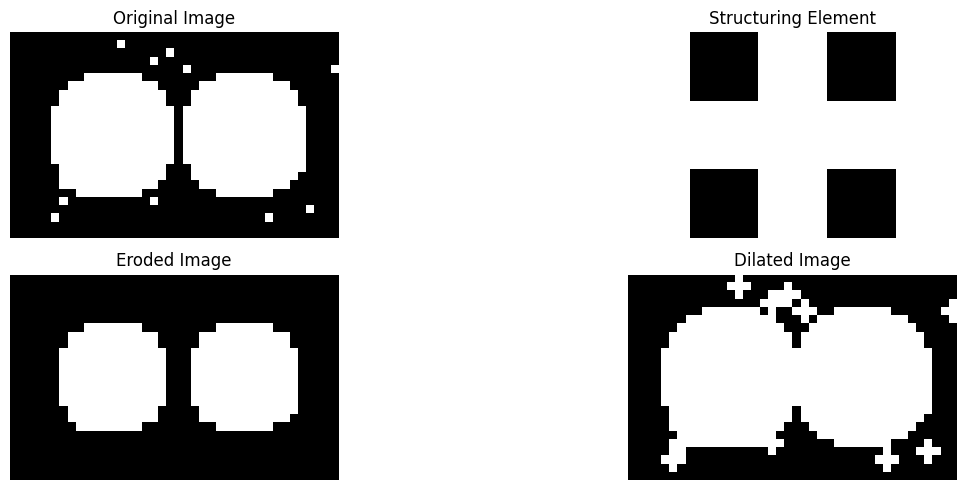

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
SE=np.array([[0,1,0],[1,1,1], [0,1,0]])
#plt.imshow(element, cmap='gray')
#to demonstrate how morphological operations work, letus create two adjacent circles with random noise on its backgraound.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1

for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1
image=circle_image
#define morphological erosion and dilation functions
def custom_erosion(image, SE):
  eroded_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  se_rows, se_cols=SE.shape
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      #extract the region of interest
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.all(region[SE==1]==1):
        #check if all SE element match the region
        eroded_image[i-1, j-1]=1
  return eroded_image

def custom_dilation(image, SE):
  dilated_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  se_rows, se_cols=SE.shape
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      #extract the region of interest
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.any(region[SE==1]==1):
        #check if any SE element match the region
        dilated_image[i-1, j-1]=1
  return dilated_image


#perform erosion and dilation
eroded_image=custom_erosion(image,SE)
dilated_image=custom_dilation(image,SE)

#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(SE, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(eroded_image, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(dilated_image, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()



# 3. Using Numpy array, create an image with two circle and a structuring wlwment. Perform successive (Two times) morphological Erosion and Dilation using built-in function. Sho the original image, SE, eroded image and dilated image side by side in a subplot with a title.

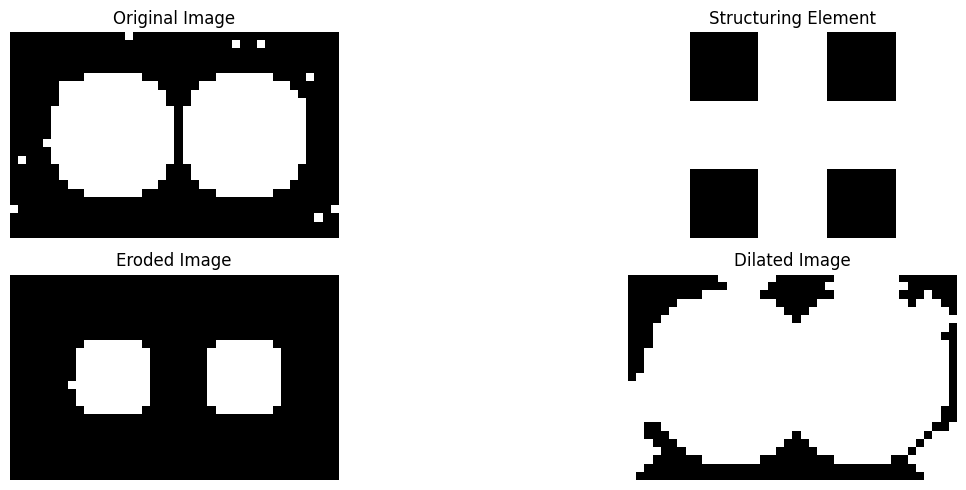

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.draw import disk
from skimage.morphology import (erosion, dilation, closing, opening, area_closing, area_opening)
from skimage.color import rgb2gray

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
element=np.array([[0,1,0],[1,1,1],[0,1,0]])
#plt.imshow(element, cmap='gray');

# to demonstrate how morphological operations work, let us create two adjacent circle with random noise on its bg.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1
for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1

#imshow(circle_image)
#Erosion removes islands and small objects so that only the key features will remain. Meanwhile, dilation makes objects more visible and fills in small holes in objects.

def multi_dil(im , num, element=element):
  for i in range(num):
    im=dilation(im, element)
  return im

def multi_ero(im, num, element=element):
  for i in range(num):
    im=erosion(im, element)
  return im

erosion=multi_ero(circle_image, 3)
dilation=multi_dil(circle_image, 3)

#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(circle_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(element, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(erosion, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(dilation, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()




# 4. Using Nympy array, create an image with two circle and a structuring elenment. Perform successive (two times) morphological Erosion and Dilation without using built in function. show the origianl iamge, SE,, eroded image and dilated image side by side in a subplot with a title.

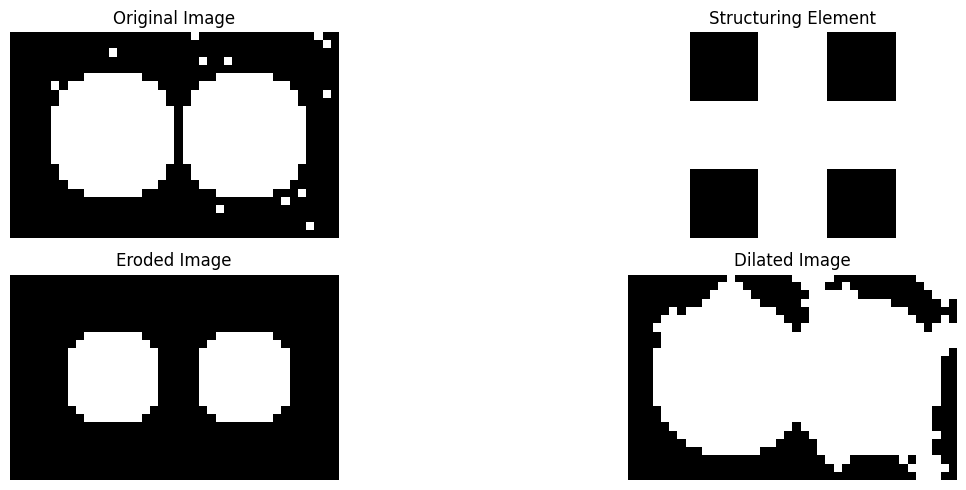

In [13]:
import numpy as np
import matplotlib.pyplot as plt

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
SE=np.array([[0,1,0],[1,1,1], [0,1,0]])
#plt.imshow(element, cmap='gray')
#to demonstrate how morphological operations work, letus create two adjacent circles with random noise on its backgraound.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1

for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1
image=circle_image
#define morphological erosion and dilation functions
def custom_erosion(image, SE):
  eroded_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.all(region[SE==1]==1):
        eroded_image[i-1, j-1]=1
  return eroded_image

def custom_dilation(image, SE):
  dilated_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  se_rows, se_cols=SE.shape
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.any(region[SE==1]==1):
        dilated_image[i-1, j-1]=1
  return dilated_image

def successive_erosion(image, SE, iterations):
  eroded_image=image.copy()
  for _ in range(iterations):
    eroded_image=custom_erosion(eroded_image, SE)
  return eroded_image

def successive_dilation(image, SE, iterations):
  dilated_image=image.copy()
  for _ in range(iterations):
    dilated_image=custom_dilation(dilated_image, SE)
  return dilated_image

#perform successive erosion and dilation
iterations=2
eroded_image_successive=successive_erosion(image, SE, iterations)
dilated_image_successive=successive_dilation(image, SE, iterations)


#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(SE, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(eroded_image_successive, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(dilated_image_successive, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()



# 5. Using Numpy array , create an image with two circle and a structuring elemnent. Perform morphological opening and closing using built-in function. Show the original image, SE , opened image and closed image side by side in a subplot with a title.

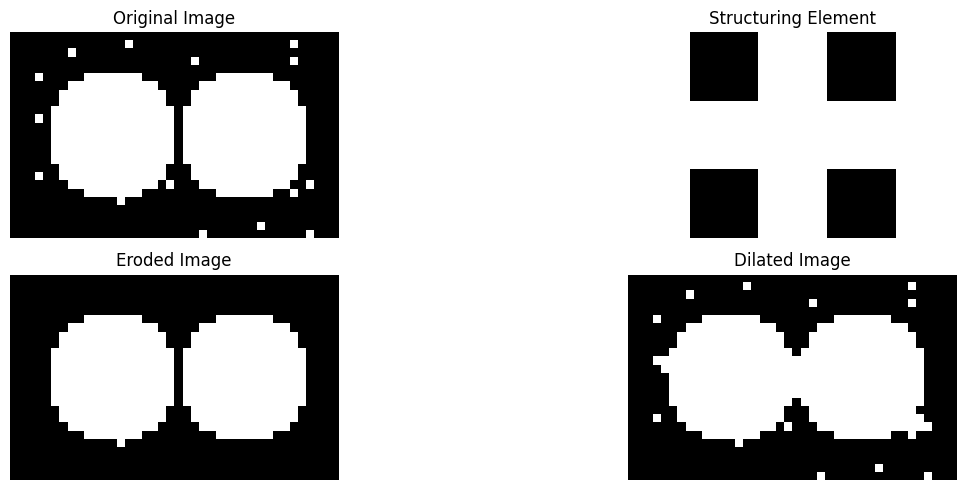

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.draw import disk
from skimage.morphology import (erosion, dilation, closing, opening, area_closing, area_opening)
from skimage.color import rgb2gray

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
element=np.array([[0,1,0],[1,1,1],[0,1,0]])
#plt.imshow(element, cmap='gray');

# to demonstrate how morphological operations work, let us create two adjacent circle with random noise on its bg.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1
for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1

#imshow(circle_image)
#Erosion removes islands and small objects so that only the key features will remain. Meanwhile, dilation makes objects more visible and fills in small holes in objects.
opening=opening(circle_image, element);
closing=closing(circle_image, element);


#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(circle_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(element, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(opening, cmap='gray')
plt.title('Eroded Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(closing, cmap='gray')
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()


# 6. Using Numpy array, create an image with two circle and a structuring element. Perform morphological opening and closing without using built in function. Show the original image, SE, opened image and closed image side by side in a subplot with a title.

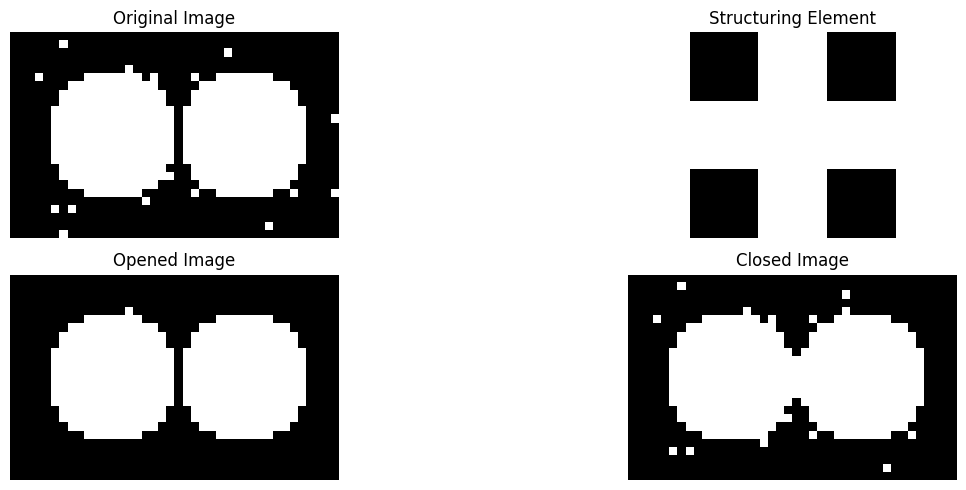

In [16]:
import numpy as np
import matplotlib.pyplot as plt

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
SE=np.array([[0,1,0],[1,1,1], [0,1,0]])
#plt.imshow(element, cmap='gray')
#to demonstrate how morphological operations work, letus create two adjacent circles with random noise on its backgraound.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1

for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1
image=circle_image
#define morphological erosion and dilation functions
def custom_erosion(image, SE):
  eroded_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.all(region[SE==1]==1):
        eroded_image[i-1, j-1]=1
  return eroded_image

def custom_dilation(image, SE):
  dilated_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  se_rows, se_cols=SE.shape
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.any(region[SE==1]==1):
        dilated_image[i-1, j-1]=1
  return dilated_image

def opening(image, SE):
  eroded_image=custom_erosion(image, SE)
  opened_image=custom_dilation(eroded_image, SE)
  return opened_image

def closing(image, SE):
  dilated_image=custom_dilation(image, SE)
  closed_image=custom_erosion(dilated_image, SE)
  return closed_image

#perform opening and closing
opened_image=opening(image, SE)
closed_image=closing(image, SE)


#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(SE, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(opened_image, cmap='gray')
plt.title('Opened Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(closed_image, cmap='gray')
plt.title('Closed Image')
plt.axis('off')

plt.tight_layout()
plt.show()



# 7. Using Numpy array, create an image with two circle and a structuring element. Perform successive (3 times) morphological opening and closing without using built-in function. Show the original image, SE, opened image and closed image side by side in a subplot with a title

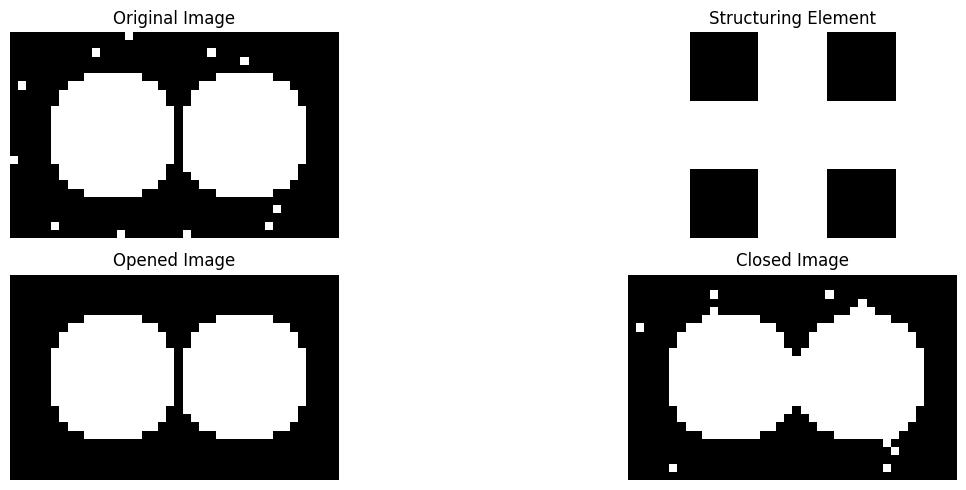

In [17]:
import numpy as np
import matplotlib.pyplot as plt

#define a structuring element. these can be an array of any size as long as it has a smaller shape than the input image.
SE=np.array([[0,1,0],[1,1,1], [0,1,0]])
#plt.imshow(element, cmap='gray')
#to demonstrate how morphological operations work, letus create two adjacent circles with random noise on its backgraound.
circle_image=np.zeros((25,40))
circle_image[disk((12,12),8)]=1
circle_image[disk((12,28),8)]=1

for x in range(20):
  circle_image[np.random.randint(25), np.random.randint(40)]=1
image=circle_image
#define morphological erosion and dilation functions
def custom_erosion(image, SE):
  eroded_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.all(region[SE==1]==1):
        eroded_image[i-1, j-1]=1
  return eroded_image

def custom_dilation(image, SE):
  dilated_image=np.zeros_like(image)
  padded_image=np.pad(image, 1, mode='constant', constant_values=0)
  se_rows, se_cols=SE.shape
  for i in range(1, padded_image.shape[0]-1):
    for j in range(1, padded_image.shape[1]-1):
      region=padded_image[i-1:i+2, j-1: j+2]
      if np.any(region[SE==1]==1):
        dilated_image[i-1, j-1]=1
  return dilated_image

def opening(image, SE, iterations=1):
  opened_image=image.copy()
  for _ in range(iterations):
    eroded_image=custom_erosion(opened_image, SE)
    opened_image=custom_dilation(eroded_image, SE)
  return opened_image

def closing(image, SE, iterations=1):
  closed_image=image.copy()
  for _ in range(iterations):
    dilated_image=custom_dilation(closed_image, SE)
    closed_image=custom_erosion(dilated_image, SE)
  return closed_image

# Number of iterations
iterations=3

#perform successive  opening and closing
opened_image_successive=opening(image, SE, iterations)
closed_image_successive=closing(image, SE, iterations)


#plot the images
plt.figure(figsize=(15,5))

#plot the original
plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,2,2)
plt.imshow(SE, cmap='gray')
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,2,3)
plt.imshow(opened_image_successive, cmap='gray')
plt.title('Opened Image')
plt.axis('off')

#plot the dilated image
plt.subplot(2,2,4)
plt.imshow(closed_image_successive, cmap='gray')
plt.title('Closed Image')
plt.axis('off')

plt.tight_layout()
plt.show()



# 8. Take a color image. Create an appropriate structuring element. Perform morphological operations to enhance the image using build in function. Show the original image, SE, and every morphological steps side by side in a subplot with a title.

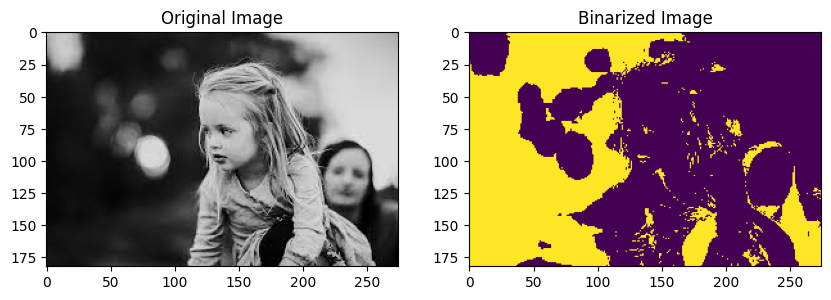

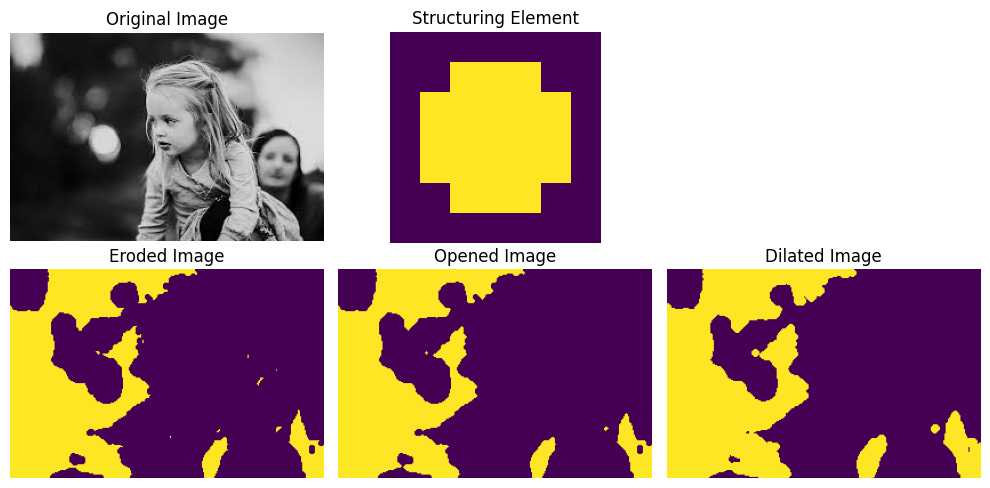

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.draw import disk
from skimage.morphology import (erosion, dilation, closing, opening, area_closing, area_opening)
from skimage.color import rgb2gray
from PIL import Image
from google.colab import drive

input_image_path="/content/drive/MyDrive/cse 3216/b&w bby.jpeg"

original_image=Image.open(input_image_path)
image_np=np.array(original_image)

#original image
leaves=original_image
binary=rgb2gray(leaves)<0.15

# plot the images
fig, ax=plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(leaves);
ax[0].set_title('Original Image')
ax[1].imshow(binary)
ax[1].set_title('Binarized Image')

# Even though we applied a low value to threshold the binary image, the binary image is still dirty . this is because of the vines and the lattice frame that is also of the same shade. Lukily the vines and lattice frame is much thinner than the leaves thus we can apply morphological operations.

# we will use a 7x7 SE because of the larger shape of the actual image
element=np.array([
    [0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,0,1,1,1,0,0],
    [0,0,0,0,0,0,0]
])

# using this structuring element, we can apply erosion operations to remove the vines and the lattice frame.
def multi_ero(im, num, element=element):
  for i in range(num):
    im=erosion(im, element)
  return im

multi_eroded=multi_ero(binary, 1, element)

#after the erosion, the majority of the unnecessary objects and artifacts are eroded.
#however, notice how there is still minute noise in some areas. we can remove this by applying the opening operation.
opened=opening(multi_eroded)

def multi_dil(im, num, element=element):
  for i in range(num):
    im=dilation(im, element)
  return im

multi_diluted=multi_dil(opened, 1, element)

#plot the images
plt.figure(figsize=(10,5))

#plot the original
plt.subplot(2,3,1)
plt.imshow(leaves)
plt.title('Original Image')
plt.axis('off')
#plot the SE
plt.subplot(2,3,2)
plt.imshow(element)
plt.title('Structuring Element')
plt.axis('off')
#plot the eroded image
plt.subplot(2,3,4)
plt.imshow(multi_eroded)
plt.title('Eroded Image')
plt.axis('off')

#plot the opened image
plt.subplot(2,3,5)
plt.imshow(opened)
plt.title('Opened Image')
plt.axis('off')

#plot the dilated img
plt.subplot(2,3,6)
plt.imshow(multi_diluted)
plt.title('Dilated Image')
plt.axis('off')

plt.tight_layout()
plt.show()


# 9. Color image: custom (no built-ins) morphology

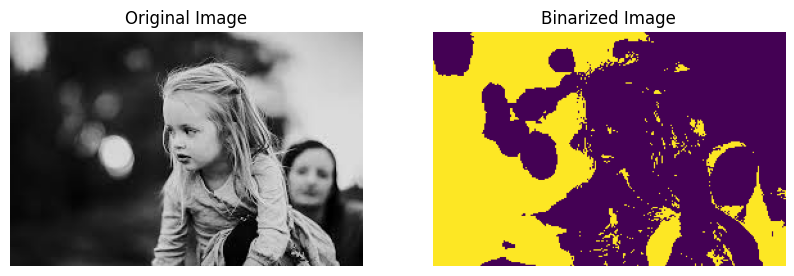

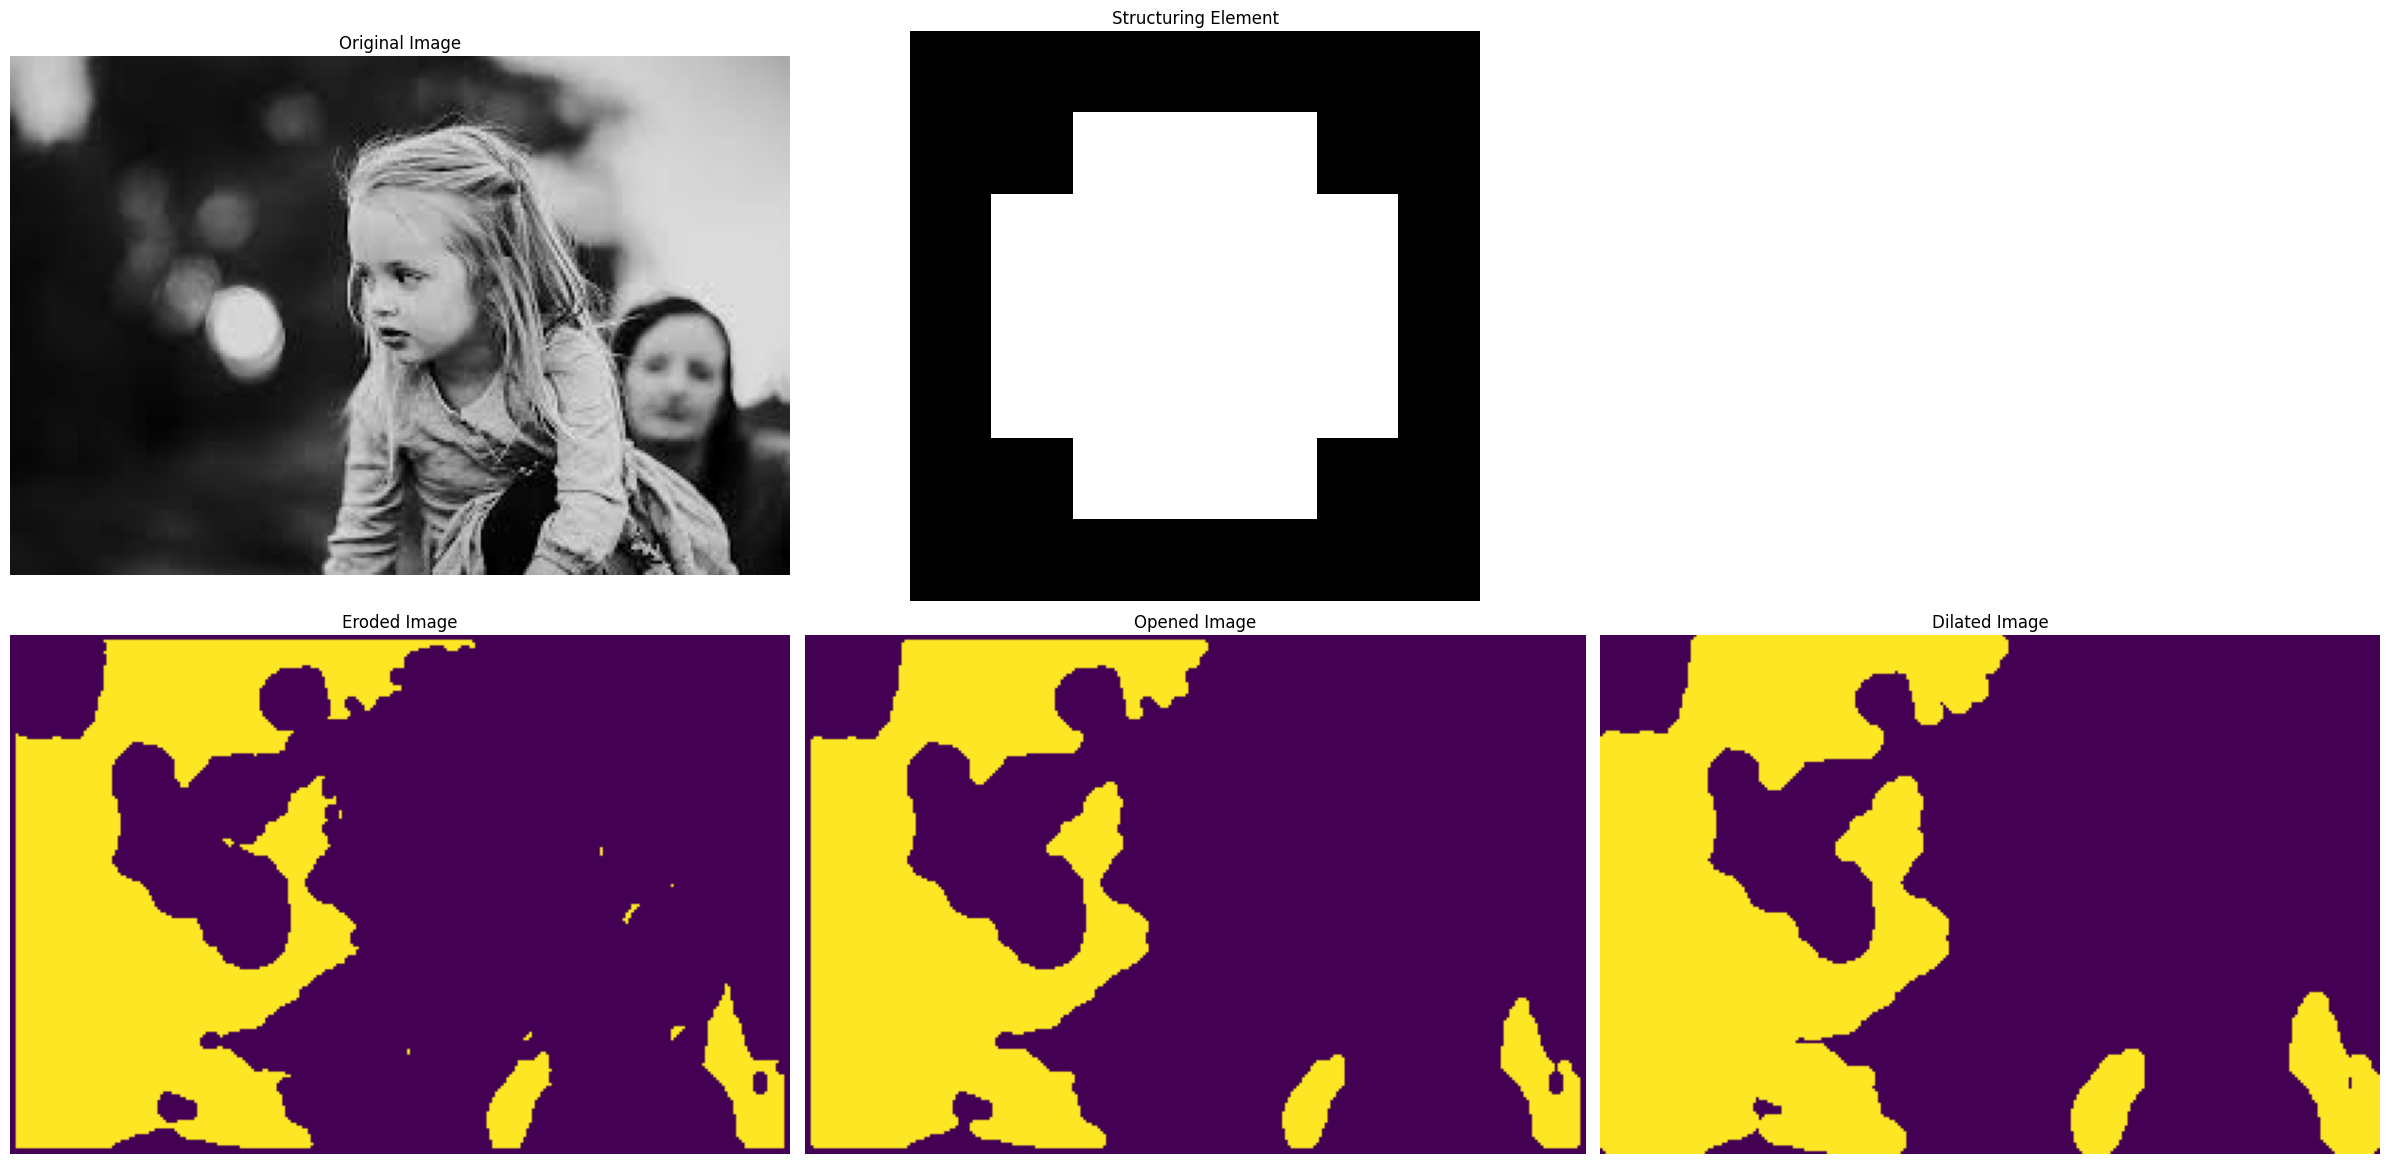

In [1]:
# Lab Task 9 — Color image: custom (no built-ins) morphology
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.draw import disk
from skimage.morphology import erosion, dilation, closing, opening, area_closing, area_opening  # (not used here)
from skimage.color import rgb2gray
from PIL import Image

# If you are using Google Colab, uncomment the next two lines:
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)

# ---------------- Load the color image ----------------
# Replace with your own path
input_image_path = "/content/drive/MyDrive/cse 3216/b&w bby.jpeg"
original_image = Image.open(input_image_path)
image_np = np.array(original_image)   # Use original_image instead of image

# Original image
leaves = original_image
# Binarized image (threshold on grayscale)
binary = rgb2gray(leaves) < 0.15
image = binary

# ---------------- Quick preview ----------------
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(leaves); ax[0].set_title('Original Image'); ax[0].axis('off')
ax[1].imshow(image);  ax[1].set_title('Binarized Image'); ax[1].axis('off')
plt.show()

# Even with a low threshold the binary image is still dirty due to thin vines/lattice.
# We will use a 7×7 structuring element for larger shapes.
SE = np.array([
    [0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,1,1,1,1,1,0],
    [0,0,1,1,1,0,0],
    [0,0,0,0,0,0,0],
])

# ---------------- Custom morphology (no built-ins) ----------------
def custom_erosion(image, SE):
    eroded_image = np.zeros_like(image)
    pad_width = SE.shape[0] // 2        # padding based on SE size
    padded_image = np.pad(image, pad_width, mode='constant', constant_values=0)
    se_rows, se_cols = SE.shape
    for i in range(pad_width, padded_image.shape[0] - pad_width):
        for j in range(pad_width, padded_image.shape[1] - pad_width):
            # region of interest (adjusting for padding)
            region = padded_image[i - pad_width:i + pad_width + 1,
                                  j - pad_width:j + pad_width + 1]
            # apply erosion condition
            if np.all(region[SE == 1] == 1):
                eroded_image[i - pad_width, j - pad_width] = 1  # set pixel
    return eroded_image

def custom_dilation(image, SE):
    dilated_image = np.zeros_like(image)
    pad_width = SE.shape[0] // 2        # padding based on SE size
    padded_image = np.pad(image, pad_width, mode='constant', constant_values=0)
    se_rows, se_cols = SE.shape
    for i in range(pad_width, padded_image.shape[0] - pad_width):
        for j in range(pad_width, padded_image.shape[1] - pad_width):
            region = padded_image[i - pad_width:i + pad_width + 1,
                                  j - pad_width:j + pad_width + 1]
            # apply dilation condition
            if np.any(region[SE == 1] == 1):
                dilated_image[i - pad_width, j - pad_width] = 1  # set pixel
    return dilated_image

# Successive operations
def successive_erosion(image, SE, iterations):
    eroded_image = image.copy()
    for _ in range(iterations):
        eroded_image = custom_erosion(eroded_image, SE)
    return eroded_image

def successive_dilation(image, SE, iterations):
    dilated_image = image.copy()
    for _ in range(iterations):
        dilated_image = custom_dilation(dilated_image, SE)
    return dilated_image

# Opening = erosion then dilation
def opening_custom(image, SE):
    eroded_image = custom_erosion(image, SE)
    opened_image = custom_dilation(eroded_image, SE)
    return opened_image

# Closing = dilation then erosion
def closing_custom(image, SE):
    dilated_image = custom_dilation(image, SE)
    closed_image = custom_erosion(dilated_image, SE)
    return closed_image

# ---------------- Run the pipeline ----------------
iterations = 1
eroded_image_successive = successive_erosion(image, SE, iterations)   # remove vines/lattice
opened_image = opening_custom(eroded_image_successive, SE)            # clean residual tiny noise
dilated_image_successive = successive_dilation(opened_image, SE, iterations)

# ---------------- Plot all results ----------------
plt.figure(figsize=(24, 12))

plt.subplot(2, 3, 1)
plt.imshow(leaves); plt.title('Original Image'); plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(SE, cmap='gray'); plt.title('Structuring Element'); plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(eroded_image_successive); plt.title('Eroded Image'); plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(opened_image); plt.title('Opened Image'); plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(dilated_image_successive); plt.title('Dilated Image'); plt.axis('off')

plt.tight_layout()
plt.show()